# Work Planning Prototype

**Background**: In our previous notebooks, we have a collection of techniques for performing, allocating, and analyzing our work. We anticipate that the scope of work will be greater than our hardware's ability to complete in a single charge. We should therefore carefully plan the work we aim to do in advance of arriving at a work site so that we come much more prepared.


Perhaps we follow a plan like:
- Prepare region image
    - Consolidate to single geotiff
    - Re-project CRS
    - Filter, smooth, simplify, downsample
- Parition region into manageable pieces
    - Call them "work areas/sites", e.g. 1/2 acre spaces
- Segmentation & masking?
- Plan macro/micro routes
    - Macro: 1/2 acre work spaces
    - Micro: route between plants in a work space
- Execute? Store execution results? Analyze performance?


## Prepare Region Image

- Consolidate to single geotiff
- Reproject CRS
- Image pre-processing

In [2]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
file_path = '../input/IGNORE_Brewster-ortho.tif'


In [ ]:
# Reproject region to geographic CRS

## Parition Region
- Create outline polygon of full work region
    - Simplify geometry for faster execution
- Divide full region into working areas

In [3]:
simplification_tolerance = 5

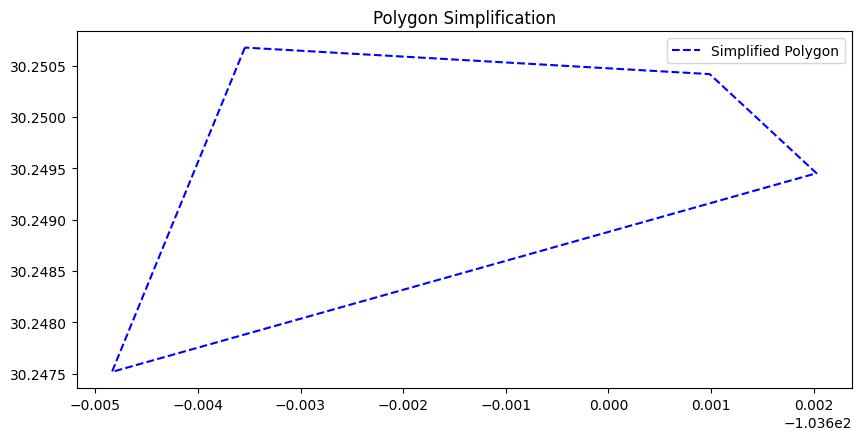

In [4]:
from plant_search.region_partition import extract_region_contour

import matplotlib.pyplot as plt
import geopandas as gpd


region_contour_gpd = extract_region_contour(file_path, simplification_tolerance)
simplified_polygon = region_contour_gpd.geometry.iloc[0]

fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Polygon")
plt.legend()
plt.title("Polygon Simplification")
plt.show()